# Predicting Heart Disease is present or not

####     Heart disease is one of the leading causes of death worldwide, and early detection plays a crucial role in reducing mortality rates. This project aims to predict the presence of heart disease in patients using machine learning techniques based on the data.


In [1]:
# Importing the libraries
import pandas as pd

In [42]:
# loading the datasets
target_df =pd.read_csv('labels.csv')
features_df =pd.read_csv('values.csv')

In [43]:
target_df.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [44]:
features_df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [45]:
features_df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0


In [46]:
# merging the both dataframes for further analysis
data =pd.merge(features_df, target_df, on="patient_id", how ="inner")

In [47]:
#  Basic checks
data.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [48]:
data.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [54]:
data.shape

(180, 15)

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [56]:
data.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [57]:
# checking the null values
data.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

######           ---So there is 0 null values present in the data

In [58]:
data.heart_disease_present.value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

# Domain Analysis

####    The dataset is provided in two CSV files. The labels file contains patient identifier along with the target variable indicating whether heart disease is present or not. 
####     The values file contains the same patient identifier along with 13 medical attributes describing the patient’s health condition. Both files are         merged  using the patient ID to create a single dataset for analysis and model building.
####    The objective of this analysis is to understand patient health attributes and identify patterns associated with the presence of heart disease.
####     Heart disease is the leading cause of death for both men and women. More than half of the deaths due to heart disease in 2009 were in men.
### Features 
####    There are 14 columns in the dataset, where the patient_id column is a unique and random identifier. 
####    1.slope_of_peak_exercise_st_segment (type: int): the slope of the peak exercise ST segment, an electrocardiography read out indicating quality
####     of blood flow to the heart.
####    2.thal (type: categorical): results of thallium stress test measuring blood flow to the heart, with possible values normal, fixed_defect, reversible_defect.
####     3.resting_blood_pressure (type: int): resting blood pressure
####    4.chest_pain_type (type: int): chest pain type (4 values)
####    5.num_major_vessels (type: int)number of major vessels (0-3) colored by flourosopy
####    6.fasting_blood_sugar_gt_120_mg_per_dl (type: binary): fasting blood sugar > 120 mg/dl
####    7.•	resting_ekg_results (type: int): resting electrocardiographic results (values 0,1,2)
####    8.serum_cholesterol_mg_per_dl (type: int): serum cholestoral in mg/dl
#####   9.oldpeak_eq_st_depression (type: float): oldpeak = ST depression induced by exercise relative to rest, a measure of abnormality in electrocardiograms
####     10.sex (type: binary): 0: female, 1: male
####     11.	age (type: int): age in years
####     12.	max_heart_rate_achieved (type: int): maximum heart rate achieved (beats per minute)
####     13.exercise_induced_angina (type: binary): exercise-induced chest pain (0: False, 1: True)
 




###   Exploratory data analysis

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

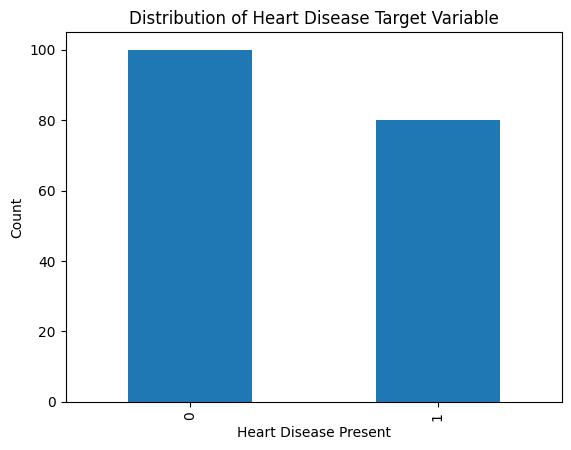

In [60]:
data['heart_disease_present'].value_counts().plot(kind='bar')
plt.xlabel("Heart Disease Present")
plt.ylabel("Count")
plt.title("Distribution of Heart Disease Target Variable")
plt.show()


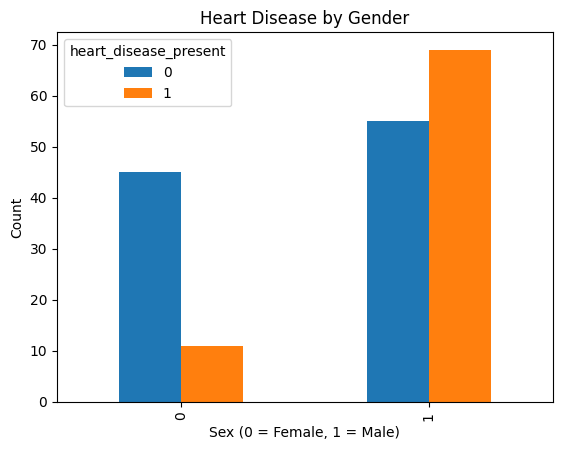

In [61]:
# compairing male vs female risk
pd.crosstab(data['sex'], data['heart_disease_present']).plot(kind='bar')
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.title("Heart Disease by Gender")
plt.show()


#####     there is higher chance of heart disease  in male

<Axes: xlabel='chest_pain_type', ylabel='Count'>

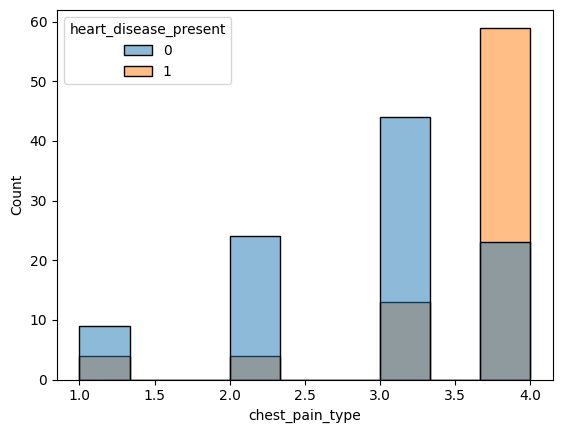

In [27]:
# Analyzing relationship between chest_pain_typa and heart_disease_present)
sns.histplot(x ='chest_pain_type',hue ='heart_disease_present',data =data)

#####    As the number of higher chest pain in patients there is high chance of heart disease presence.

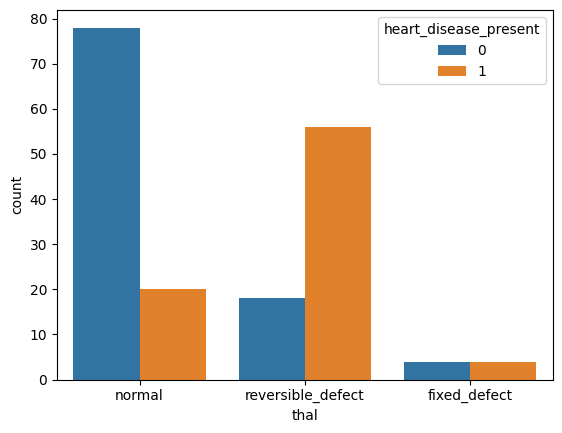

In [28]:
#
sns.countplot(x ='thal',hue ='heart_disease_present', data =data)
plt.show()

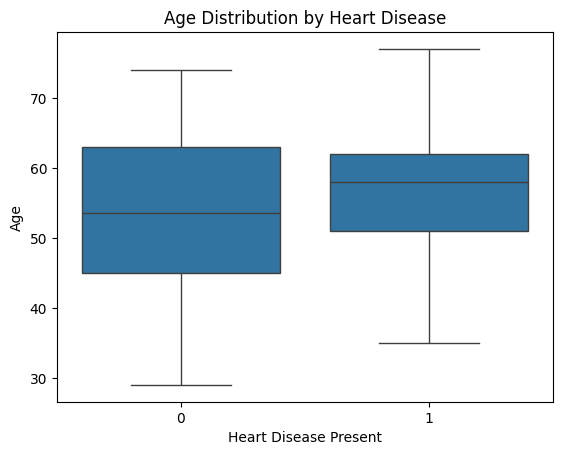

In [51]:
sns.boxplot(data =data, x ='heart_disease_present',y='age')
plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Age")
plt.show()

#####    Heart disease appears more common in older individuals
#####    Median age for heart disease patients is higher
######    Although there is noticable impact on heart disease risk.

In [ ]:
# plotting subplots

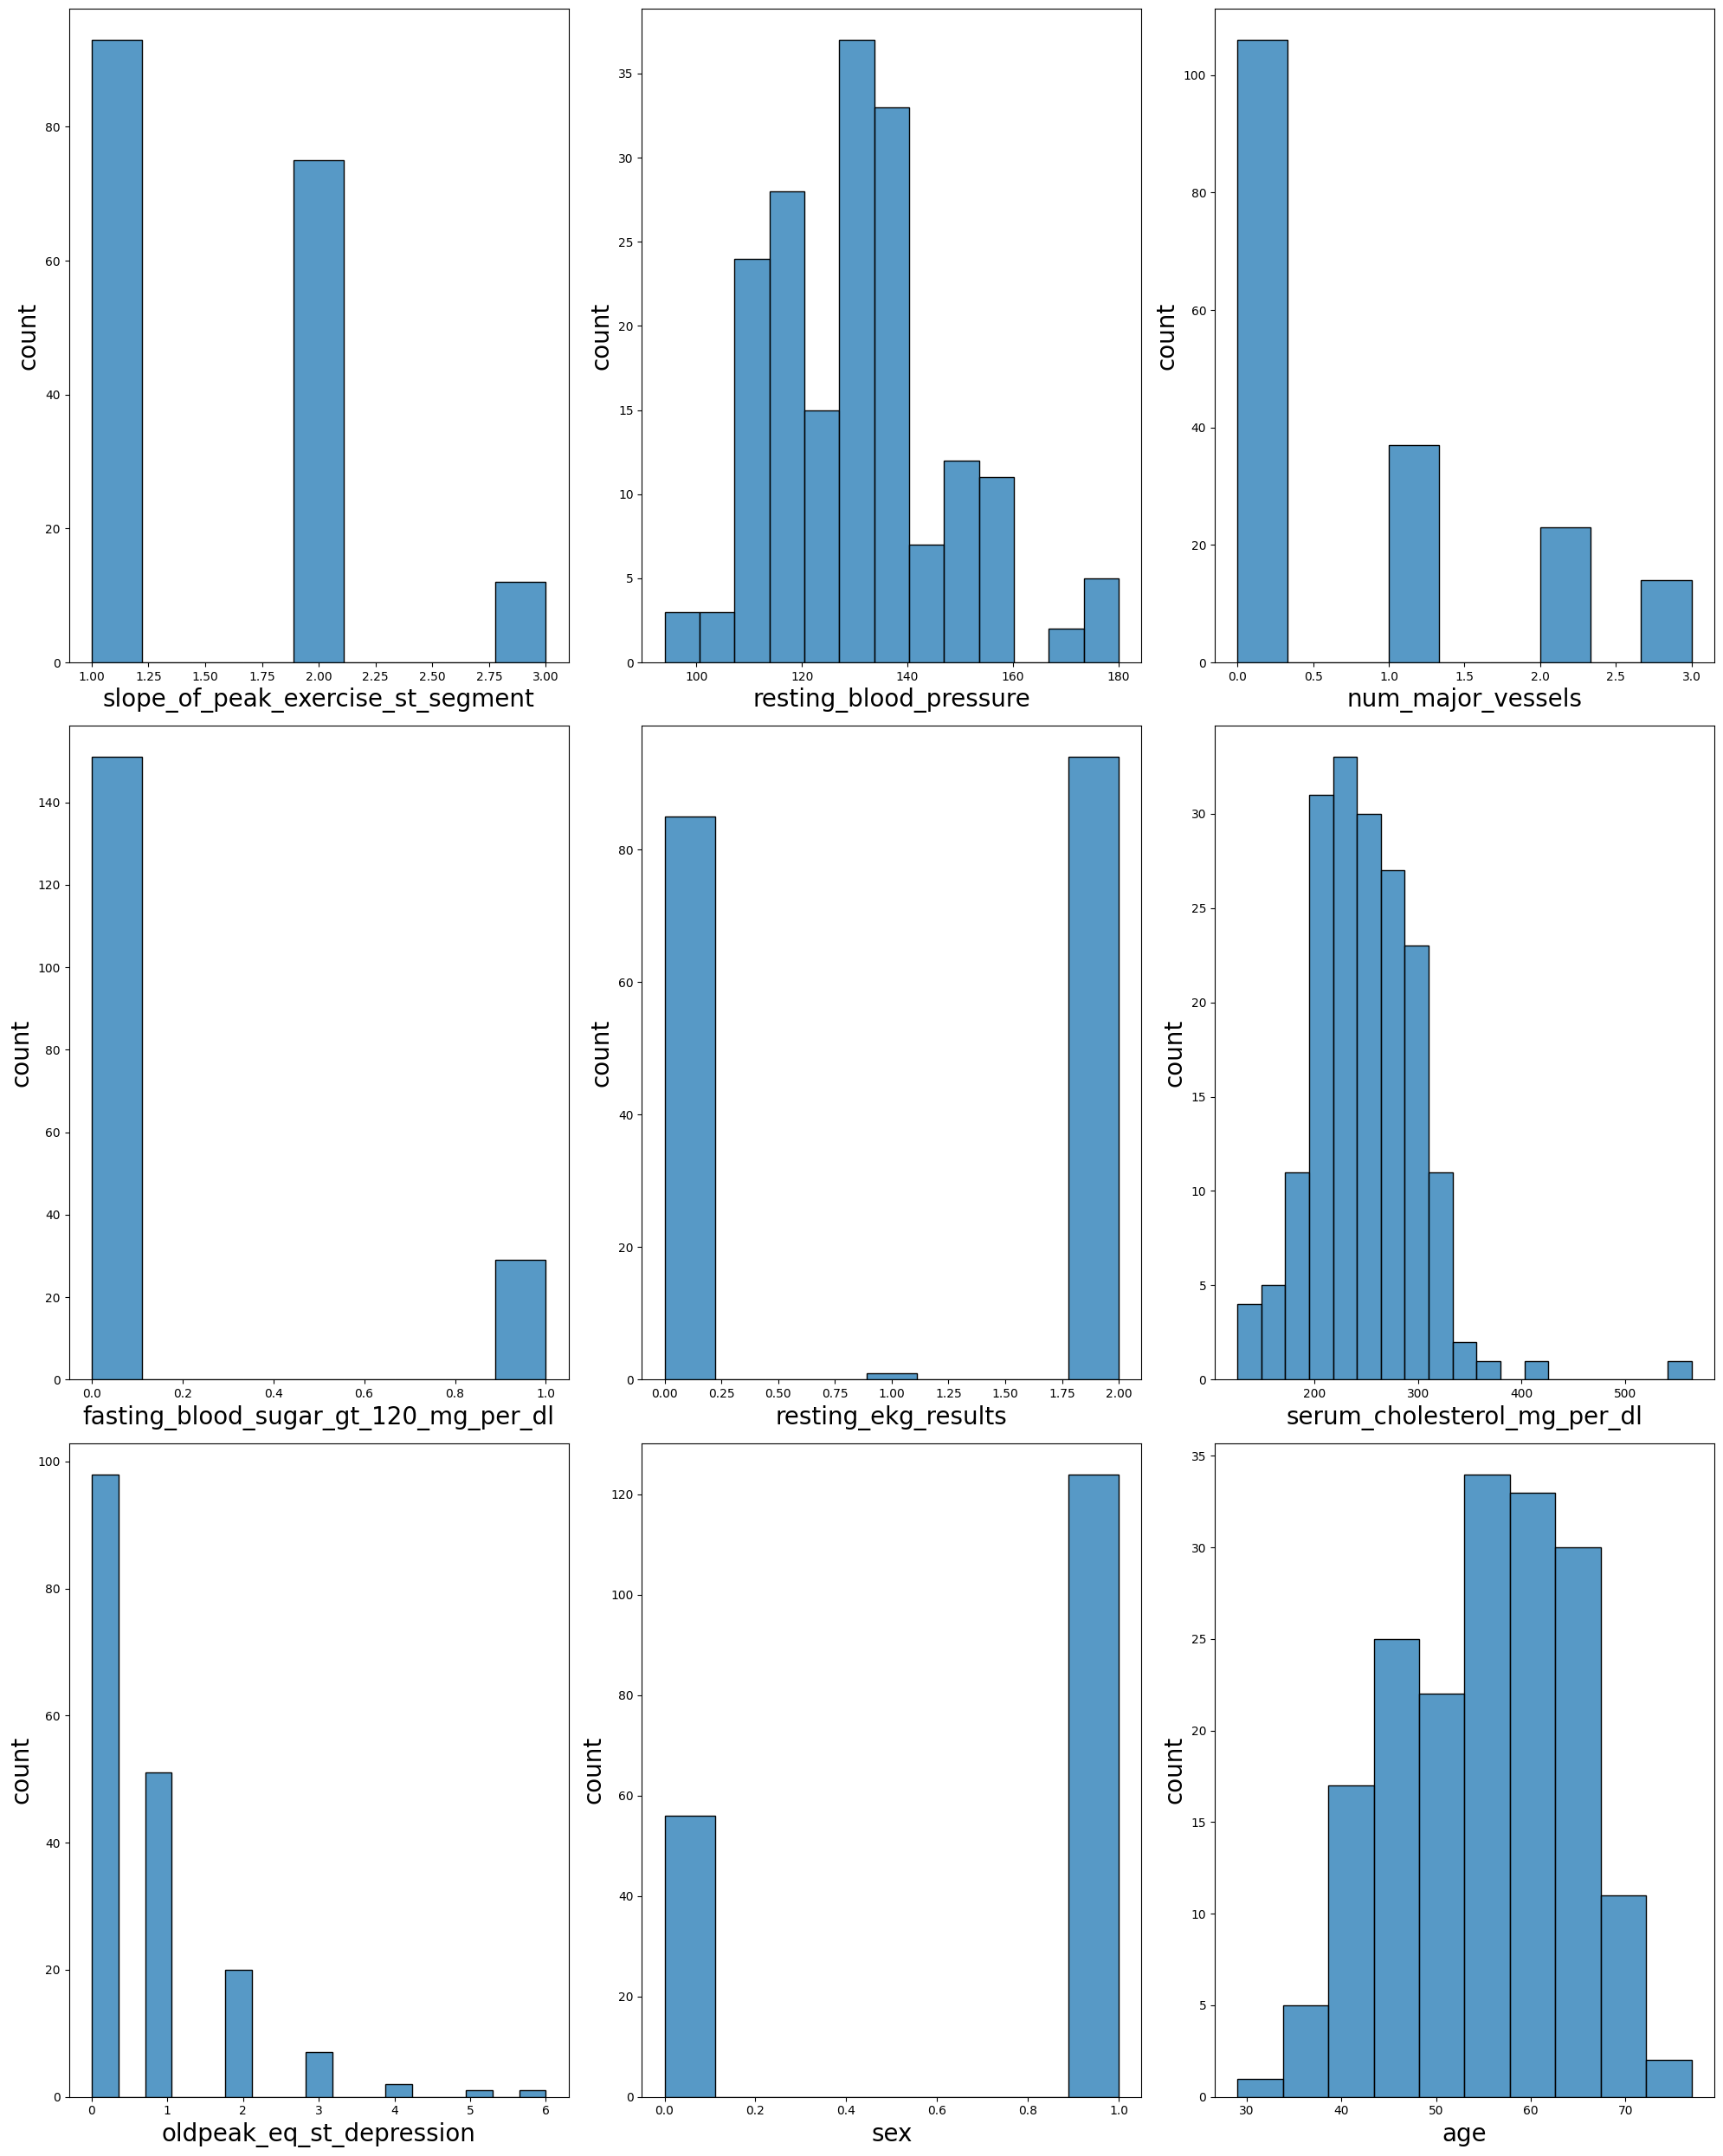

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber <=9:
        ax =plt.subplot(3,3, plotnumber)
        sns.histplot(data[column])
        plt.xlabel(column, fontsize =20)
        plt.ylabel('count',fontsize =20)
    plotnumber+=1
plt.tight_layout()
    

In [62]:
# dropping patient id column 
data.drop(columns=['patient_id'], inplace=True)


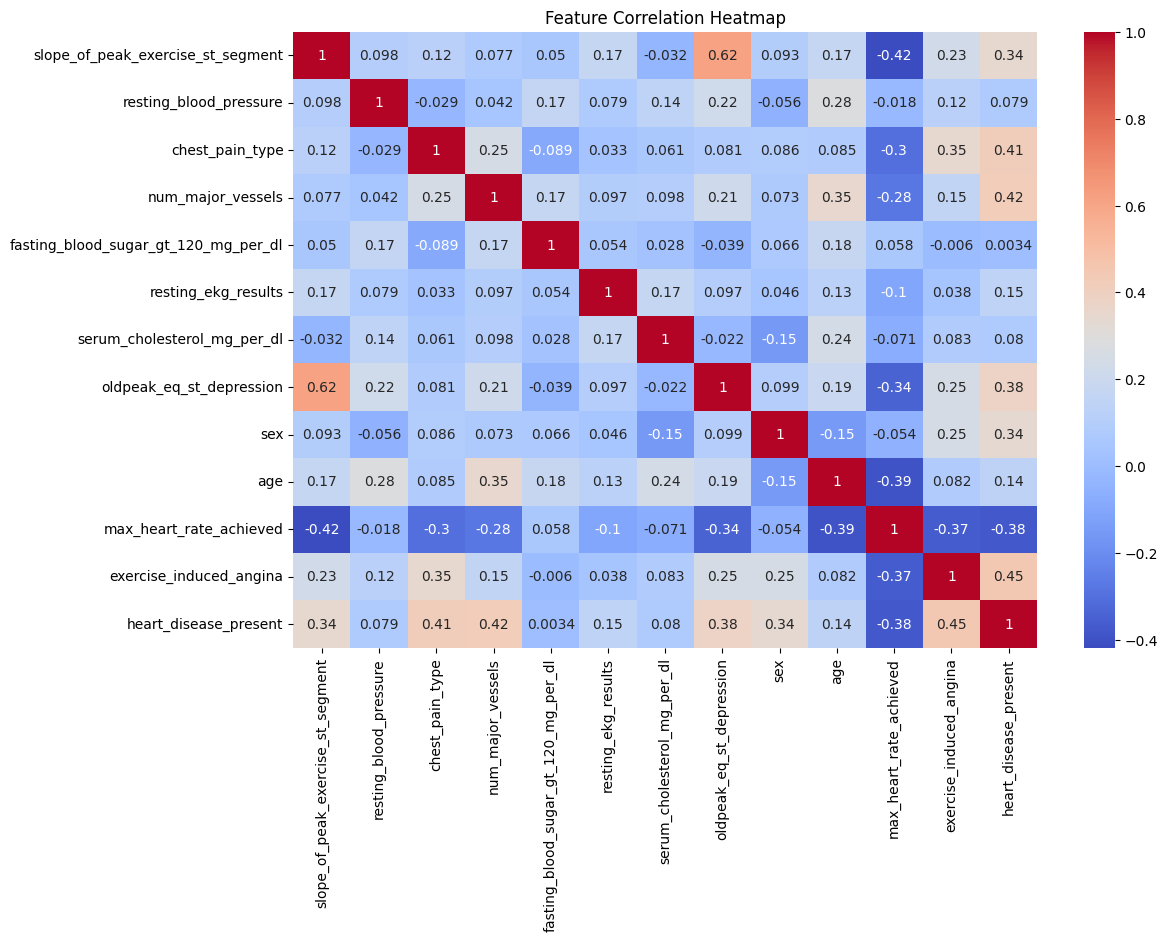

In [63]:
#Feature Relationship Analysis
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


####   The correlation heatmap is used to examine relationships between numerical features and the target variable  heart_disease_present. From the analysis, it is observed that chest pain type (cp) shows a strong positive          correlation with heart disease, indicating that certain types of chest pain are highly associated with the           presence of heart disease. Similarly, maximum heart rate achieved displays a noticeable negative           correlation, suggesting that lower heart rate capacity is linked to higher disease risk.
####    The feature oldpeak, which represents ST depression induced by exercise, demonstrates a moderate positive    correlation with heart disease, highlighting its importance as a clinical indicator. Number of major vessels also shows a positive correlation, implying that an increased number of blocked vessels raises the likelihood of heart disease.

####   Other attributes such as age, resting blood pressure, and serum_cholestrol_mg_per_dl exhibit weak to moderate correlations, indicating that while they contribute to risk, they may not independently determine heart   disease presence. Additionally, no extremely high correlation was observed between predictor variables themselves, suggesting minimal multicollinearity and supporting the inclusion of these features for model training.

In [64]:
# checking unique values for thal column
data['thal'].unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

In [65]:
data['num_major_vessels'].value_counts()

num_major_vessels
0    106
1     37
2     23
3     14
Name: count, dtype: int64

In [66]:
data['fasting_blood_sugar_gt_120_mg_per_dl'].value_counts()


fasting_blood_sugar_gt_120_mg_per_dl
0    151
1     29
Name: count, dtype: int64

In [67]:
data['resting_ekg_results'].value_counts()

resting_ekg_results
2    94
0    85
1     1
Name: count, dtype: int64

In [68]:
data['serum_cholesterol_mg_per_dl'].value_counts()

serum_cholesterol_mg_per_dl
204    4
239    4
226    3
234    3
233    3
      ..
164    1
207    1
249    1
327    1
201    1
Name: count, Length: 118, dtype: int64

In [69]:
data['oldpeak_eq_st_depression'].value_counts()

oldpeak_eq_st_depression
0.0    56
1.4    11
1.6    10
1.2     9
0.2     7
0.6     7
1.0     7
0.4     7
0.8     7
1.8     6
0.1     5
2.0     5
0.5     4
2.2     4
1.5     3
1.9     3
2.4     3
2.6     3
3.4     2
3.0     2
0.3     2
2.3     2
0.9     2
4.2     2
2.8     2
3.8     1
2.5     1
3.1     1
1.3     1
1.1     1
0.7     1
3.2     1
5.6     1
6.2     1
Name: count, dtype: int64

In [70]:
data['max_heart_rate_achieved'].value_counts()

max_heart_rate_achieved
162    10
132     6
142     6
170     5
150     5
       ..
108     1
180     1
188     1
97      1
117     1
Name: count, Length: 73, dtype: int64

In [71]:
data['exercise_induced_angina'].value_counts()

exercise_induced_angina
0    123
1     57
Name: count, dtype: int64

####      Results of thallium stress test measuring blood flow to the heart, with possible values normal, fixed_defect, reversible_defect.
####      So Patients with reversible thal defects are more likely to have heart disease, whereas normal thal is associated with lower risk, 
####      and fixed defect shows no strong separation.

In [73]:
data['chest_pain_type'].unique()

array([2, 3, 4, 1])

#####     Some features in the dataset, such as chest_pain_type,  resting_ekg_results, and other num_major_vessels, are  numeric but categorical in nature, even though they are represented numerically. Machine learning algorithms require numerical input and cannot directly interpret categorical values or understand their meaning.
#####     Categorical columns were encoded to convert them into numerical form while avoiding false ordering assumptions and ensuring compatibility with machine learning models.


######      Though chest pain type is numeric but it is categorical describing the order of pain so this column need to be encoded

In [74]:
# Converting categorical column thal to numeric via OneHotEncoding
data = pd.get_dummies(data, columns=['thal'], drop_first = True)

In [75]:
data =pd.get_dummies(data, columns =['num_major_vessels','resting_ekg_results','chest_pain_type'], drop_first =True)

In [76]:
data =data.astype(int)

In [77]:
data.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,fasting_blood_sugar_gt_120_mg_per_dl,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_normal,thal_reversible_defect,num_major_vessels_1,num_major_vessels_2,num_major_vessels_3,resting_ekg_results_1,resting_ekg_results_2,chest_pain_type_2,chest_pain_type_3,chest_pain_type_4
0,1,128,0,308,0,1,45,170,0,0,1,0,0,0,0,0,1,1,0,0
1,2,110,0,214,1,0,54,158,0,0,1,0,0,0,0,0,0,0,1,0
2,1,125,0,304,0,1,77,162,1,1,1,0,0,0,1,0,1,0,0,1
3,1,152,0,223,0,1,40,181,0,1,0,1,0,0,0,0,0,0,0,1
4,3,178,0,270,4,1,59,145,0,0,0,1,0,0,0,0,1,0,0,0


# Data Analysis report

###  During the preprocessing stage, the dataset was examined for missing values, incorrect data types, and inconsistencies. Special attention was given to columns containing zero values. In medical features such as the number of major vessels and resting ekg results, zero represents a         valid clinical condition rather than missing data. Therefore, these values were retained to preserve the medical meaning of the data. Data types were also verified to ensure that numerical and categorical features were handled correctly.
###  Exploratory Data Analysis (EDA) was performed to understand the distribution and behavior of each feature. Numerical variables such as age were analyzed using boxplots to observe their distribution. Boxplots comparing age with heart disease presence revealed that individuals with heart disease generally belong to a higher age group, indicating age as an important contributing factor. However, overlap between affected and non-affected groups suggests that age alone is not sufficient to determine heart disease risk.
###   Categorical variables such as chest pain type and thalassium test  were analyzed using countplots. The analysis showed that certain chest pain types and thal categories were more frequently associated with heart disease. For example, reversible defect cases in the thal feature showed a higher count of heart disease presence, while normal thal was more common among individuals without heart disease. These observations highlight the importance of categorical features in identifying risk patterns.
###   A correlation heatmap was generated to examine relationships between numerical features and the target variable. The heatmap helped identify features that showed moderate correlation with heart disease presence, such as age and maximum heart rate achieved. It also helped in detecting correlations among features themselves, which is useful for understanding multicollinearity before model building. This step ensured that feature relationships were well understood prior to training machine learning models.
###   Since machine learning algorithms require numerical input, categorical variables were encoded using one-hot encoding. This approach was chosen to avoid imposing incorrect ordinal relationships between categories and to allow models to interpret each category independently. Encoding ensured that the dataset was fully compatible with classification algorithms while maintaining the integrity of the original information.
###   Overall, the data analysis revealed that heart disease is influenced by a combination of factors rather than a single attribute. Age, chest pain type, thal, and certain clinical measurements showed noticeable patterns related to heart disease presence. The insights gained from exploratory analysis and visualization provided a strong foundation for selecting appropriate features and proceeding with machine learning model development.

###   In conclusion, this data analysis phase successfully transformed raw clinical data into a clean, well-understood, and structured dataset. The findings from this analysis justify the use of machine learning techniques to predict heart disease and support early detection efforts in healthcare settings.



####   Feature Engineering

In [78]:
X =data.drop(['heart_disease_present'], axis=1)
y =data['heart_disease_present']

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test =train_test_split(X,y,test_size =0.2, random_state =42, stratify =y)

In [80]:
print("X train:", X_train.shape)
print("X test :", X_test.shape)
print("y train:", y_train.shape)
print("y test:", y_test.shape)

X train: (144, 19)
X test : (36, 19)
y train: (144,)
y test: (36,)


###   Feature Scaling

In [81]:
# Scaling continous features
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.fit_transform(X_test)

In [82]:
from sklearn.linear_model import LogisticRegression
model =LogisticRegression(max_iter =1000)
model.fit(X_train_scaled ,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [83]:
# predicting
y_pred =model.predict(X_test_scaled)
y_pred

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [84]:
# Evaluation of model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score,f1_score
print("Accuraccy score:",accuracy_score(y_test,y_pred))


Accuraccy score: 0.8333333333333334


In [85]:
print("confusion matrix:",confusion_matrix(y_test,y_pred))

confusion matrix: [[17  3]
 [ 3 13]]


In [86]:
print("precision score:", precision_score(y_test,y_pred))

precision score: 0.8125


In [87]:
print("recall value:", recall_score(y_test,y_pred))

recall value: 0.8125


In [88]:
print("f1 score:",f1_score( y_test,y_pred))

f1 score: 0.8125


In [89]:
print("Classification report:",classification_report(y_test,y_pred))


Classification report:               precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.81      0.81      0.81        16

    accuracy                           0.83        36
   macro avg       0.83      0.83      0.83        36
weighted avg       0.83      0.83      0.83        36



####  The model evaluation shows high recall and accuracy  indicating effective identification of patients with heart disease. Although minor misclassifications exist, the model demonstrates strong predictive capability and is suitable for early disease detection.



##   Random Forest Classifier

In [90]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import RandomizedSearchCV
rf =RandomForestClassifier( random_state =42)


In [92]:
params ={
         'n_estimators':[50,100],
         'max_depth':[5,10],
         'min_samples_split':[5,6],
         'min_samples_leaf':[2,4],
         'max_features':['sqrt']

}

In [93]:
rf_model =RandomizedSearchCV(rf, params, n_jobs =-1, cv =3, n_iter =5, verbose =1, random_state =42)

In [94]:
rf_model.fit(X_train,y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10], 'max_features': ['sqrt'], 'min_samples_leaf': [2, 4], 'min_samples_split': [5, 6], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``

In [95]:
y_pred_rf =rf_model.predict(X_test)
y_pred_rf

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1])

In [96]:
print("Accuracy score:",accuracy_score(y_test,y_pred))
print("recall score:", recall_score(y_test, y_pred))

Accuracy score: 0.8333333333333334
recall score: 0.8125


In [97]:
print("classification report:",classification_report(y_test,y_pred))

classification report:               precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.81      0.81      0.81        16

    accuracy                           0.83        36
   macro avg       0.83      0.83      0.83        36
weighted avg       0.83      0.83      0.83        36



#####        There is high recall for class 1 and balanced f1 score

## SVM

In [106]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

svc_pipeline =Pipeline([
                       ('scaler',StandardScaler()),
                    ('svc',SVC(kernel ='rbf',random_state =42))
])

svc_pipeline.fit(X_train_scaled,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [107]:
y_pred_svc =svc_pipeline.predict(X_test_scaled)

In [109]:
print("Accuracy score:", accuracy_score(y_test,y_pred_svc))
print("SVC recall:", recall_score(y_test, y_pred_svc))

Accuracy score: 0.8611111111111112
SVC recall: 0.875


In [110]:
print("classification report:", classification_report(y_test,y_pred_svc))

classification report:               precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.82      0.88      0.85        16

    accuracy                           0.86        36
   macro avg       0.86      0.86      0.86        36
weighted avg       0.86      0.86      0.86        36



####  KNN

In [98]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [102]:
knn_pipeline =Pipeline([
                      ('scaler',StandardScaler()),
                      ('knn',KNeighborsClassifier(n_neighbors =5))
])
knn_pipeline.fit(X_train_scaled,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30


In [103]:
y_pred_knn =knn_pipeline.predict(X_test_scaled)

In [104]:
print("KNN Accuracy:",accuracy_score(y_test,y_pred_knn))
print("KNN recall:", recall_score(y_test, y_pred_knn))

KNN Accuracy: 0.8333333333333334
KNN recall: 0.875


In [105]:
print("Classification report:",classification_report(y_test,y_pred_knn))

Classification report:               precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



# ---Suggestions to the Hospital

###  1.Use the model for early identification of high-risk patients

####    Hospitals can use the heart disease prediction model during routine health check-ups to identify patients who may be at higher risk, even if they do not show clear symptoms. This can help doctors take preventive steps early, such as recommending lifestyle changes, further tests, or closer monitoring, which may reduce the chances of serious cardiac events.

###  2. Support doctors in prioritizing patient care
###    The prediction results can act as an additional support tool for doctors to prioritize patients who need immediate attention. 
###    By identifying high-risk cases early, hospitals can avoid delayed treatment and improve overall patient safety, especially in emergency  and outpatient departments.

###  ---- Model Comparison Report


In [111]:
models = {
    "Logistic Regression": y_pred,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svc,
    "KNN": y_pred_knn
}

for name, preds in models.items():
    print(f"{name} Accuracy:", accuracy_score(y_test, preds))


Logistic Regression Accuracy: 0.8333333333333334
Random Forest Accuracy: 0.8055555555555556
SVM Accuracy: 0.8611111111111112
KNN Accuracy: 0.8333333333333334


####   The objective of this stage was to compare multiple machine learning classification models and identify the most suitable model for predicting the presence of heart disease while minimizing misclassification of high-risk patients.
####    All models trained on the same dataset and evaluated on a stratified  test set.
####    Logistic reagression served the baseline model and gave the good recall, indicating effective detection of heart disease cases.
####    Random Forest Classifier achieved the moderate accuracy score ,provided the strong recall and f1 score for effective heart disease cases.
####    SVM  and knn gave the balanced precision and recall, required .


####   ---Among all evaluated models, SVC  demonstrated superior performance in predicting heart disease, particularly in identifying high-risk patients. Its robustness, high recall, and ability to capture complex relationships make it the most suitable model  for this task.

#  ---- Report on challlenges faced


###   1. Understanding and Merging Multiple Data Files
####   One of the initial challenges was working with two separate CSV files containing patient information. Identifying the correct common key(patient ID) and ensuring a proper merge without losing or duplicating records required careful verification.


###   2.Handling Categorical and Numerical Features
####  Several columns were numerically encoded but actually represented categorical medical information, such as chest pain type, resting EkG results, and thalassemia. Deciding which columns required encoding and which could be used as numerical features was challenging and required both domain understanding and experimentation.

### 3.Interpreting Zero Values

###   Some columns contained many zero values, which created confusion during preprocessing. It was necessary to carefully analyze whether zeroindicated missing data or a valid medical category (for example, number of major vessels). Incorrect handling could have led to misleading results.


###   4.Choosing the Right Evaluation Metric
###   Accuracy alone was not sufficient due to the medical nature of the problem. Understanding why recall was more important for detecting heart disease cases and learning to interpret classification reports correctly was a key challenge.

###   5. Model Selection and Comparison
###  Implementing and comparing multiple models such as Logistic Regression, Random Forest, SVM, and KNN required understanding the strengths and limitations of each algorithm. Ensuring fair comparison using the same data split and evaluation criteria was an important learning experience.

###  6.Interpreting Results in a Medical Context

####   Translating model outputs into meaningful medical insights was challenging. The focus was not only on performance scores but also on        understanding how the predictions could help reduce missed diagnoses and support clinical decision-making.